In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../..'))
sys.path.append(parent_dir)
from functions.set_plot_settings import setPlotSettings
setPlotSettings(font=True)

In [3]:
tmagic = pd.read_csv('tmagic_vs_z.txt', sep=r'\s+', names=["z", "t"])
toffs = pd.read_csv('toffs_vs_z.txt', sep=r'\s+', names=["z", "t"])

In [4]:
tmagic

,z,t
0,-425.0,-0.771238
1,-175.0,0.134920
2,75.0,1.041078
3,325.0,1.947237
4,575.0,2.853395
...,...,...
374,130125.0,485.571380
375,130575.0,487.262880
376,130825.0,488.202610
377,131275.0,489.894120


In [5]:
toffs

,z,t
0,-425.0,1.796243
1,-175.0,1.796243
2,75.0,1.796243
3,325.0,1.796243
4,575.0,1.796243
...,...,...
374,130125.0,1.819043
375,130575.0,1.819043
376,130825.0,1.819043
377,131275.0,1.819043


In [6]:
ttotal = tmagic.copy()
ttotal['t'] = tmagic['t']+toffs['t']
ttotal

,z,t
0,-425.0,1.025005
1,-175.0,1.931163
2,75.0,2.837321
3,325.0,3.743480
4,575.0,4.649638
...,...,...
374,130125.0,487.390423
375,130575.0,489.081923
376,130825.0,490.021653
377,131275.0,491.713163


In [7]:
tlin = [np.min(tmagic['t']),np.max(tmagic['t'])]
zlin = [np.min(tmagic['z']),np.max(tmagic['z'])]

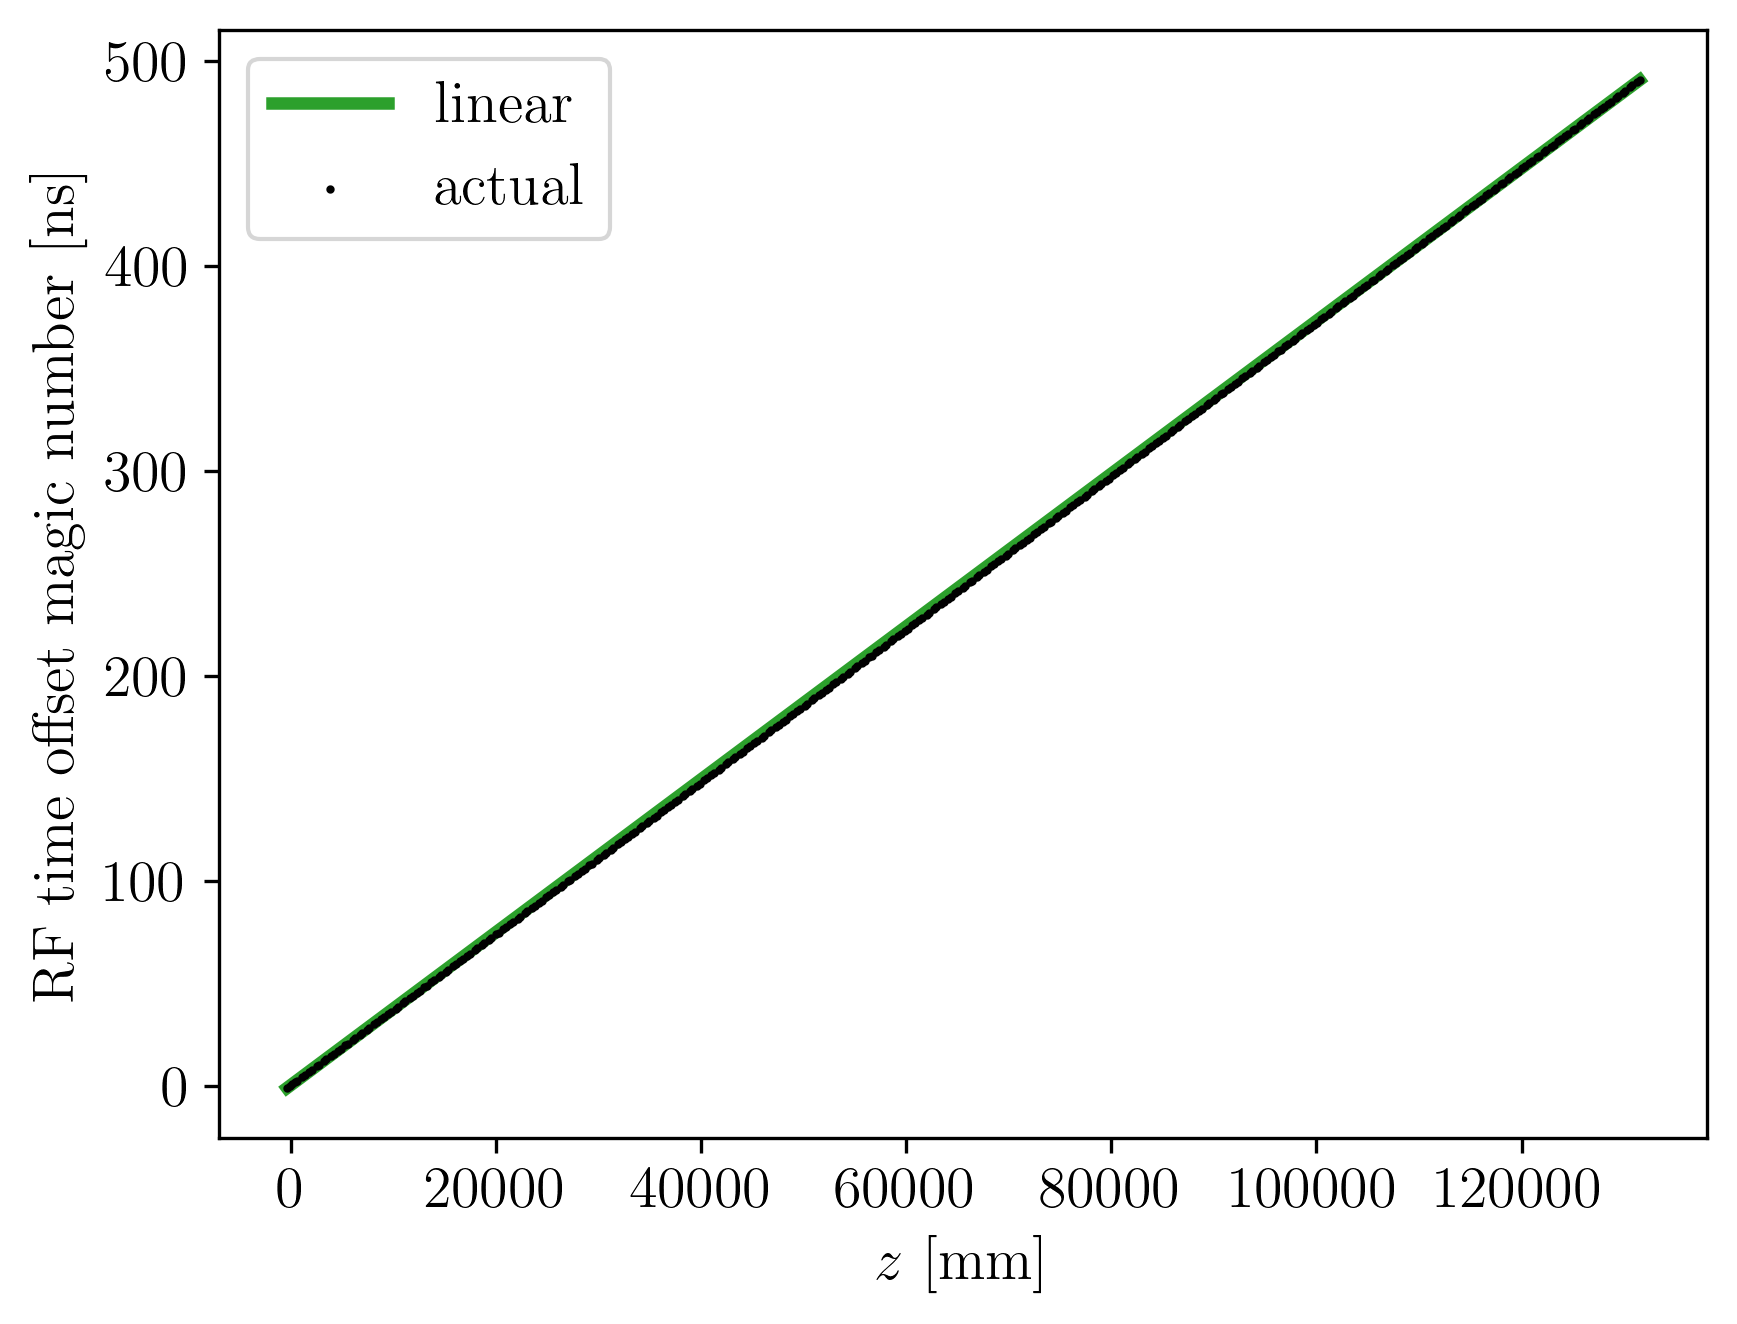

In [8]:
# plt.plot(tmagic['z'],tmagic['t'],color='tab:green',zorder=0,linewidth=3)
plt.plot(zlin,tlin,color='tab:green',zorder=0,linewidth=3,label='linear')
plt.scatter(tmagic['z'],tmagic['t'],s=1,color='black',label='actual')
plt.xlabel('$z$ [mm]')
plt.ylabel('RF time offset magic number [ns]')
plt.legend();

In [9]:
#position of first absorber
zabsi = 2250+4200
zabsf = 3650+29*4200

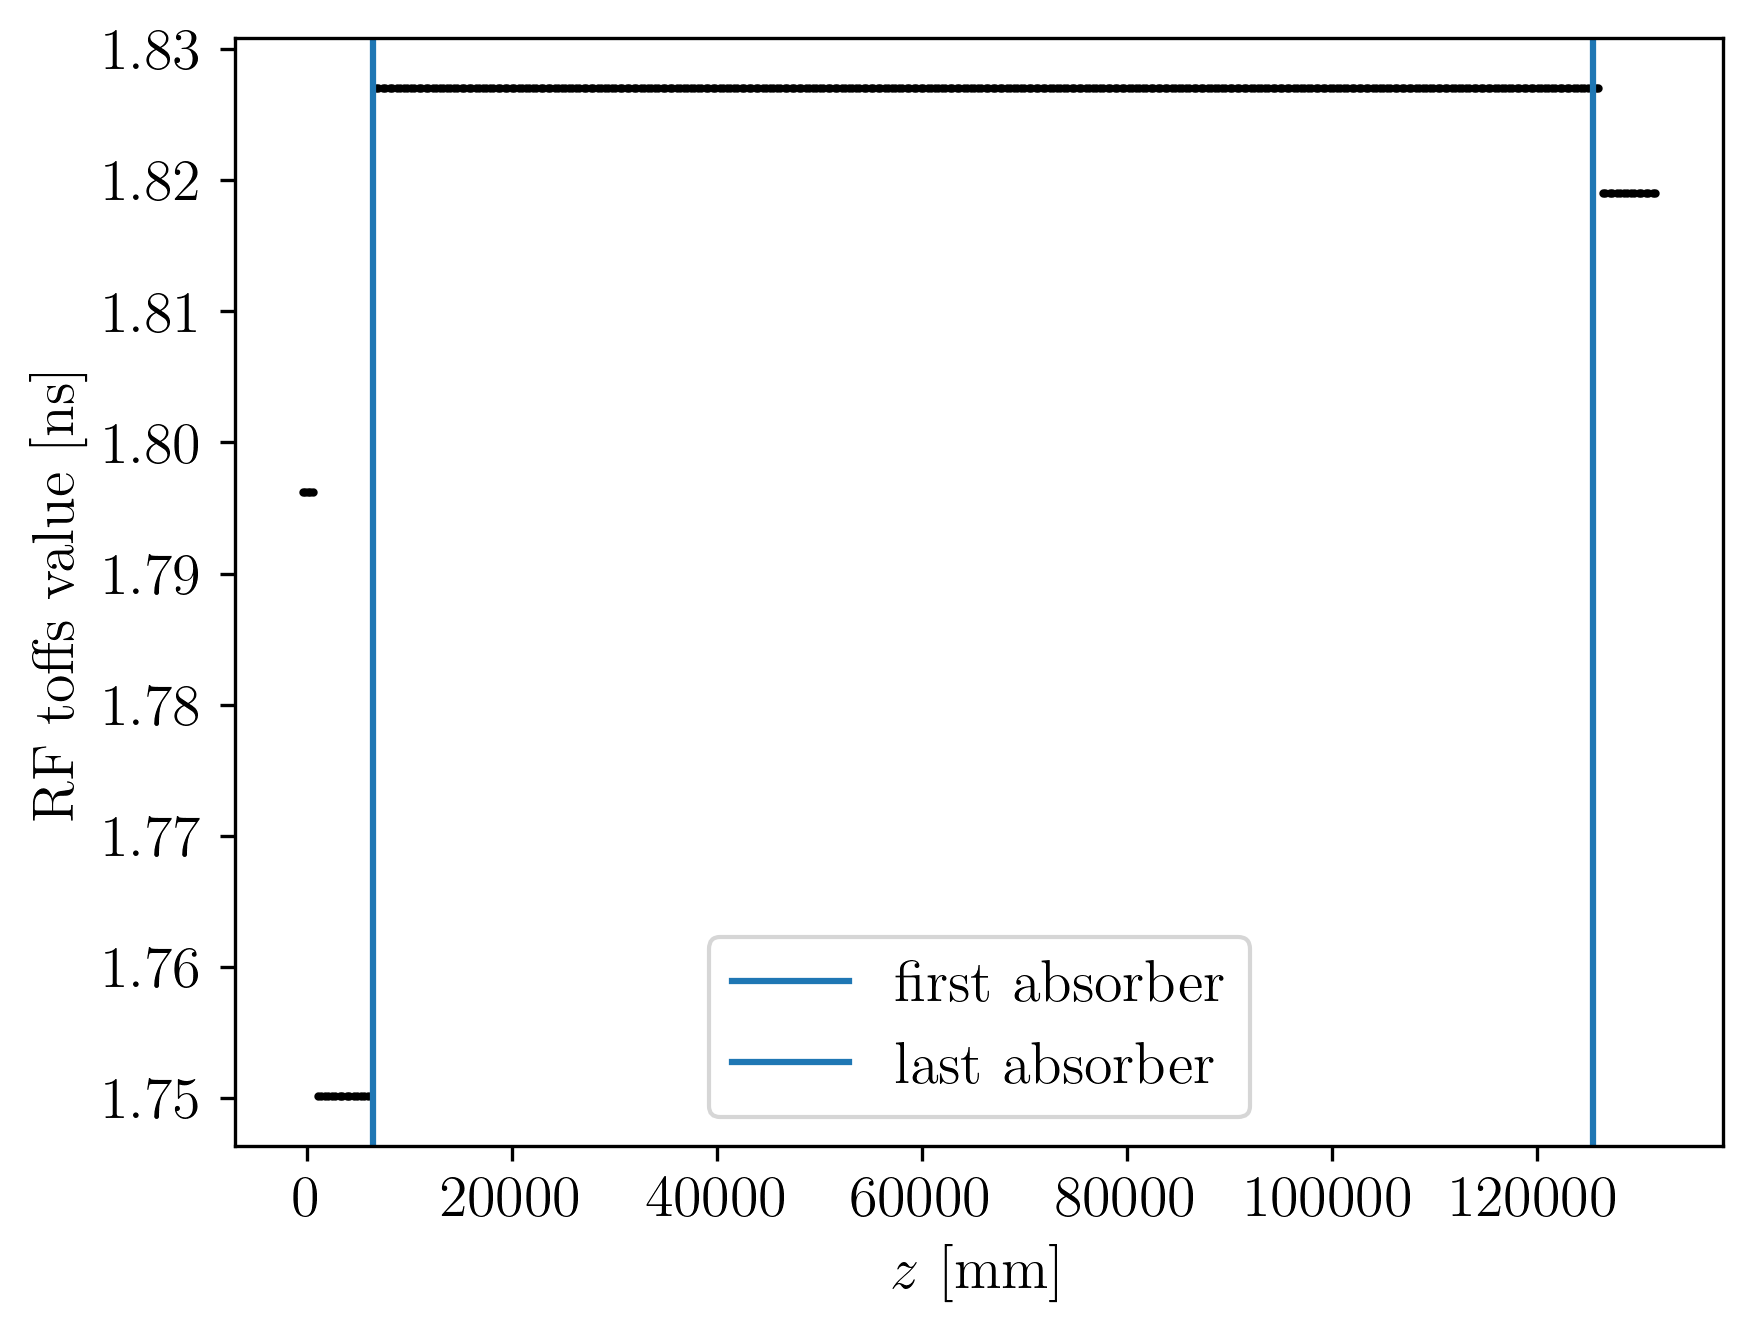

In [10]:
plt.scatter(toffs['z'],toffs['t'],s=1,color='black')
plt.xlabel('$z$ [mm]')
plt.ylabel('RF toffs value [ns]')
plt.axvline(zabsi,label='first absorber')
plt.axvline(zabsf,label='last absorber')
plt.legend();

In [11]:
tlin2 = [np.min(ttotal['t']),np.max(ttotal['t'])]
zlin2 = [np.min(ttotal['z']),np.max(ttotal['z'])]

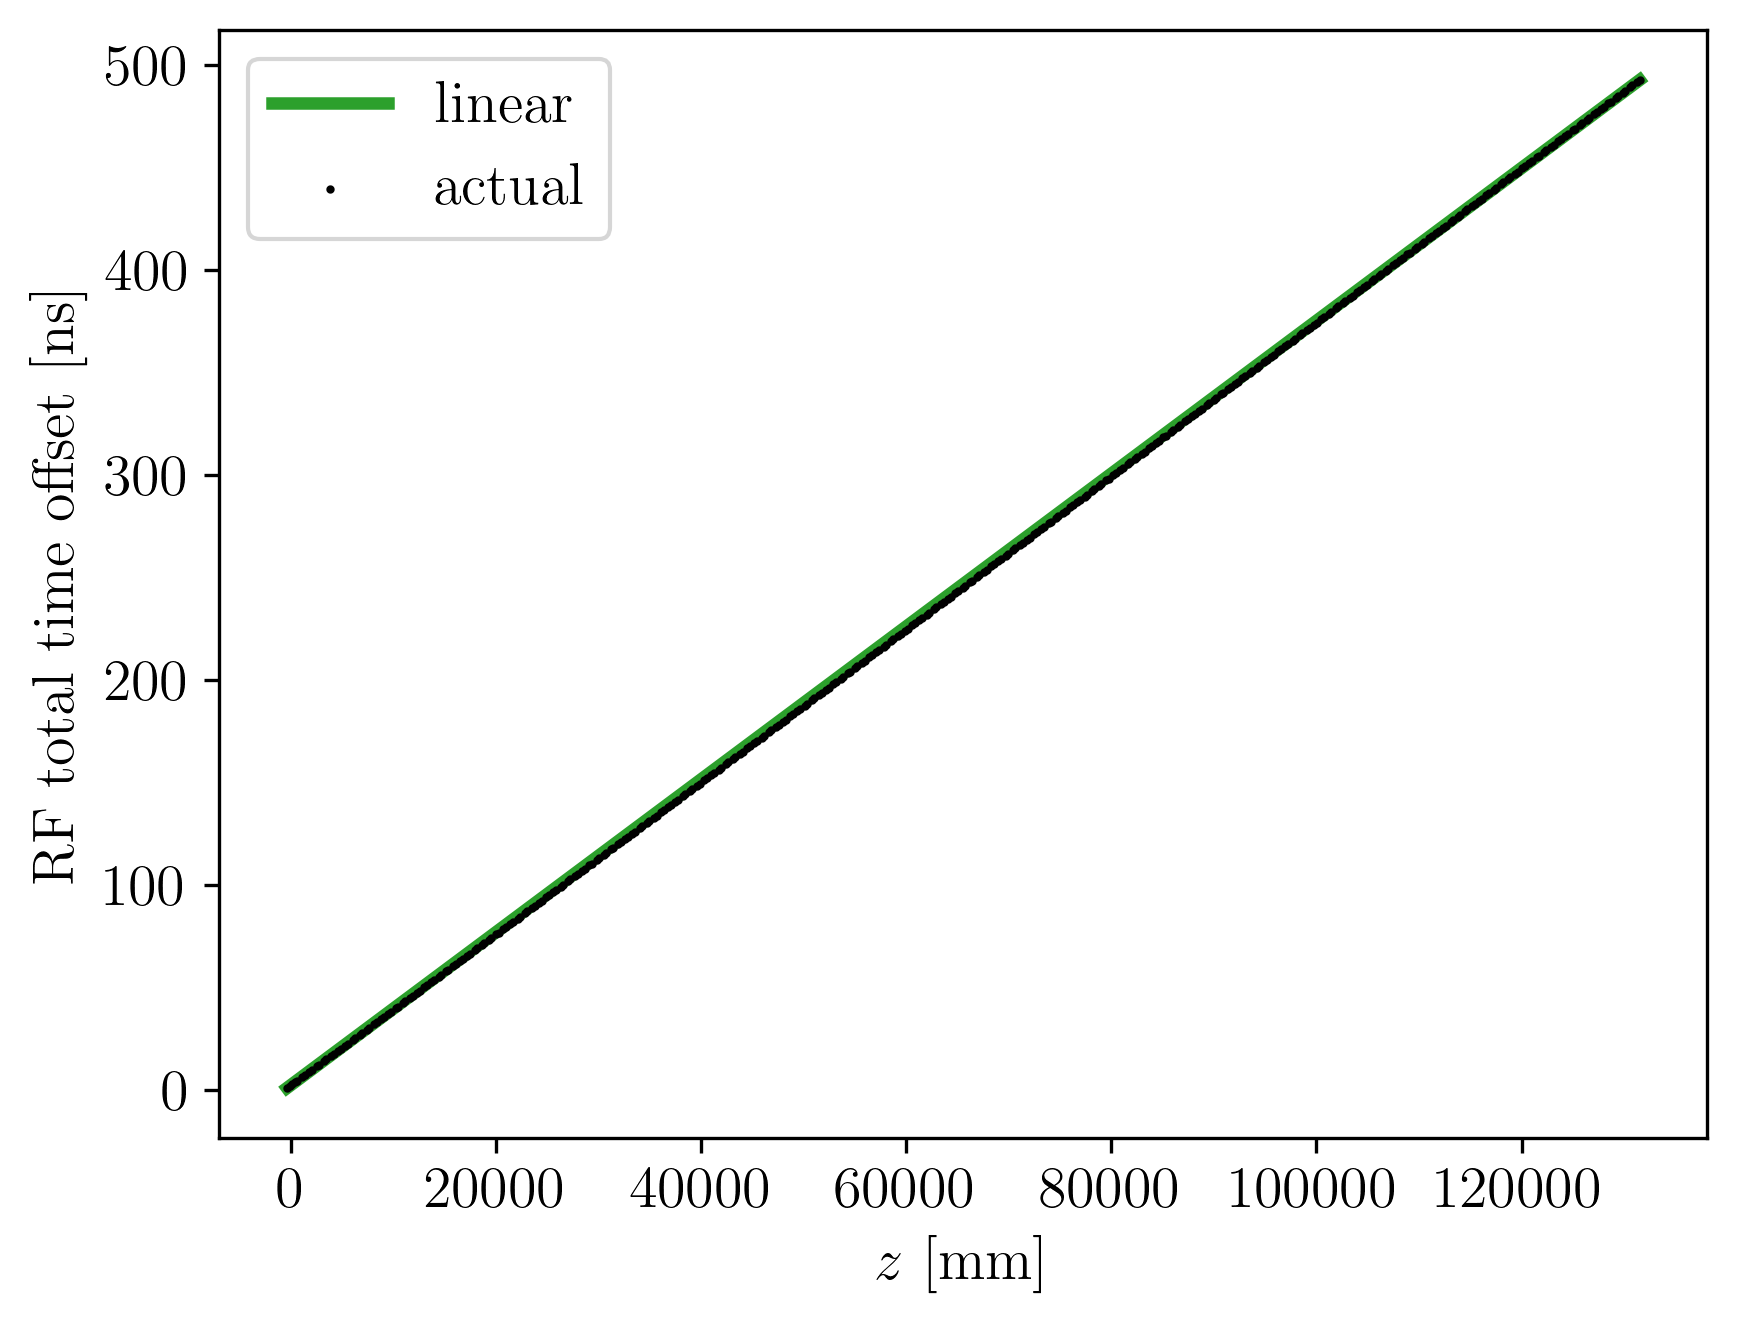

In [12]:
plt.plot(zlin2,tlin2,color='tab:green',zorder=0,linewidth=3,label='linear')
plt.scatter(ttotal['z'],ttotal['t'],s=1,color='black',label='actual')
plt.xlabel('$z$ [mm]')
plt.ylabel('RF total time offset [ns]')
plt.legend();

In [13]:
# RF frequency:
fRF = 325e6
# RF period:
TRF = 1/fRF

In [14]:
modvals = []
for i in range(len(ttotal['t'])):
    modvals.append(ttotal['t'][i] % TRF)

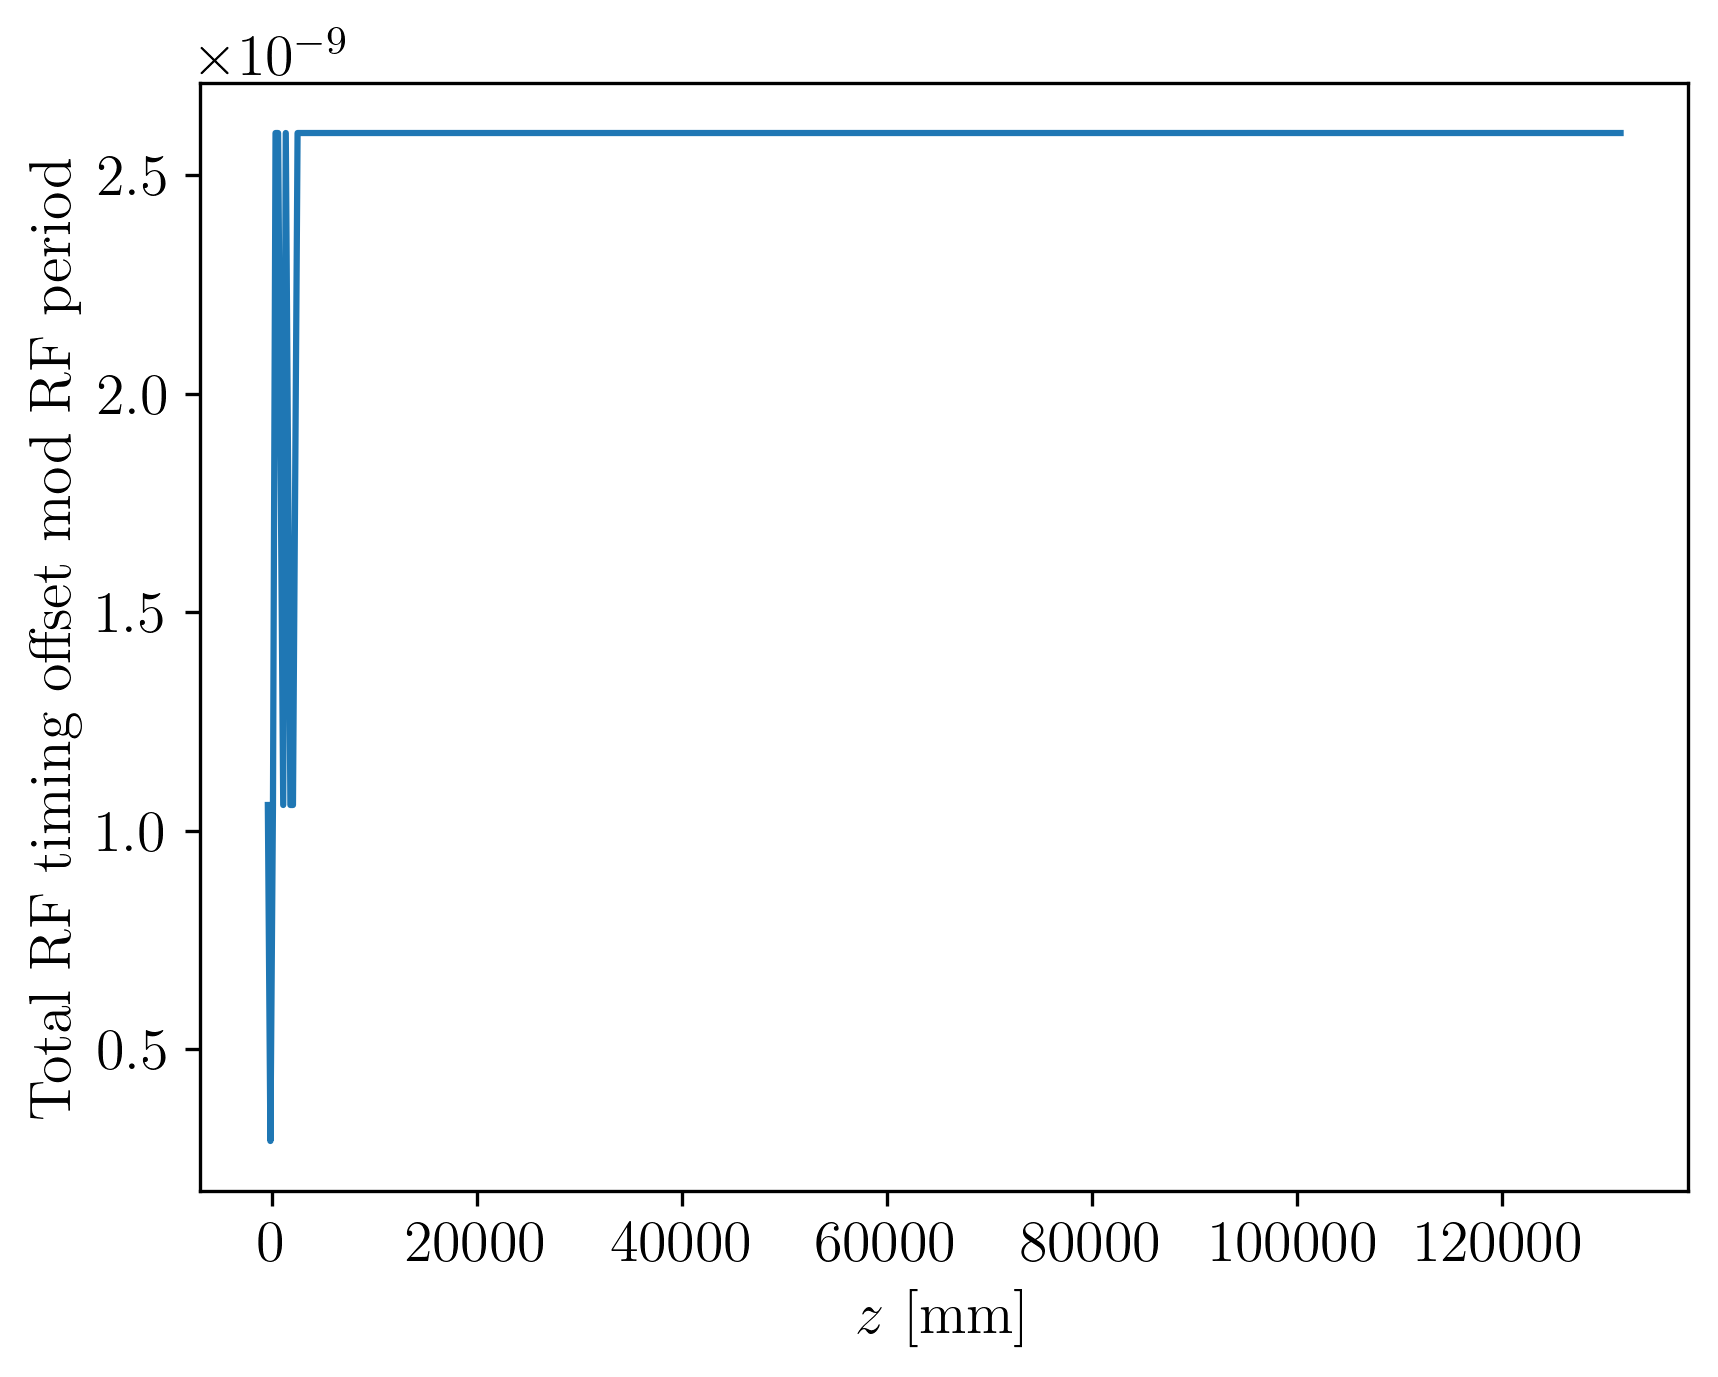

In [15]:
# plt.scatter(ttotal['z'], modvals, s=2, color='black')
plt.plot(ttotal['z'], modvals)
plt.xlabel('$z$ [mm]')
plt.ylabel('Total RF timing offset mod RF period');

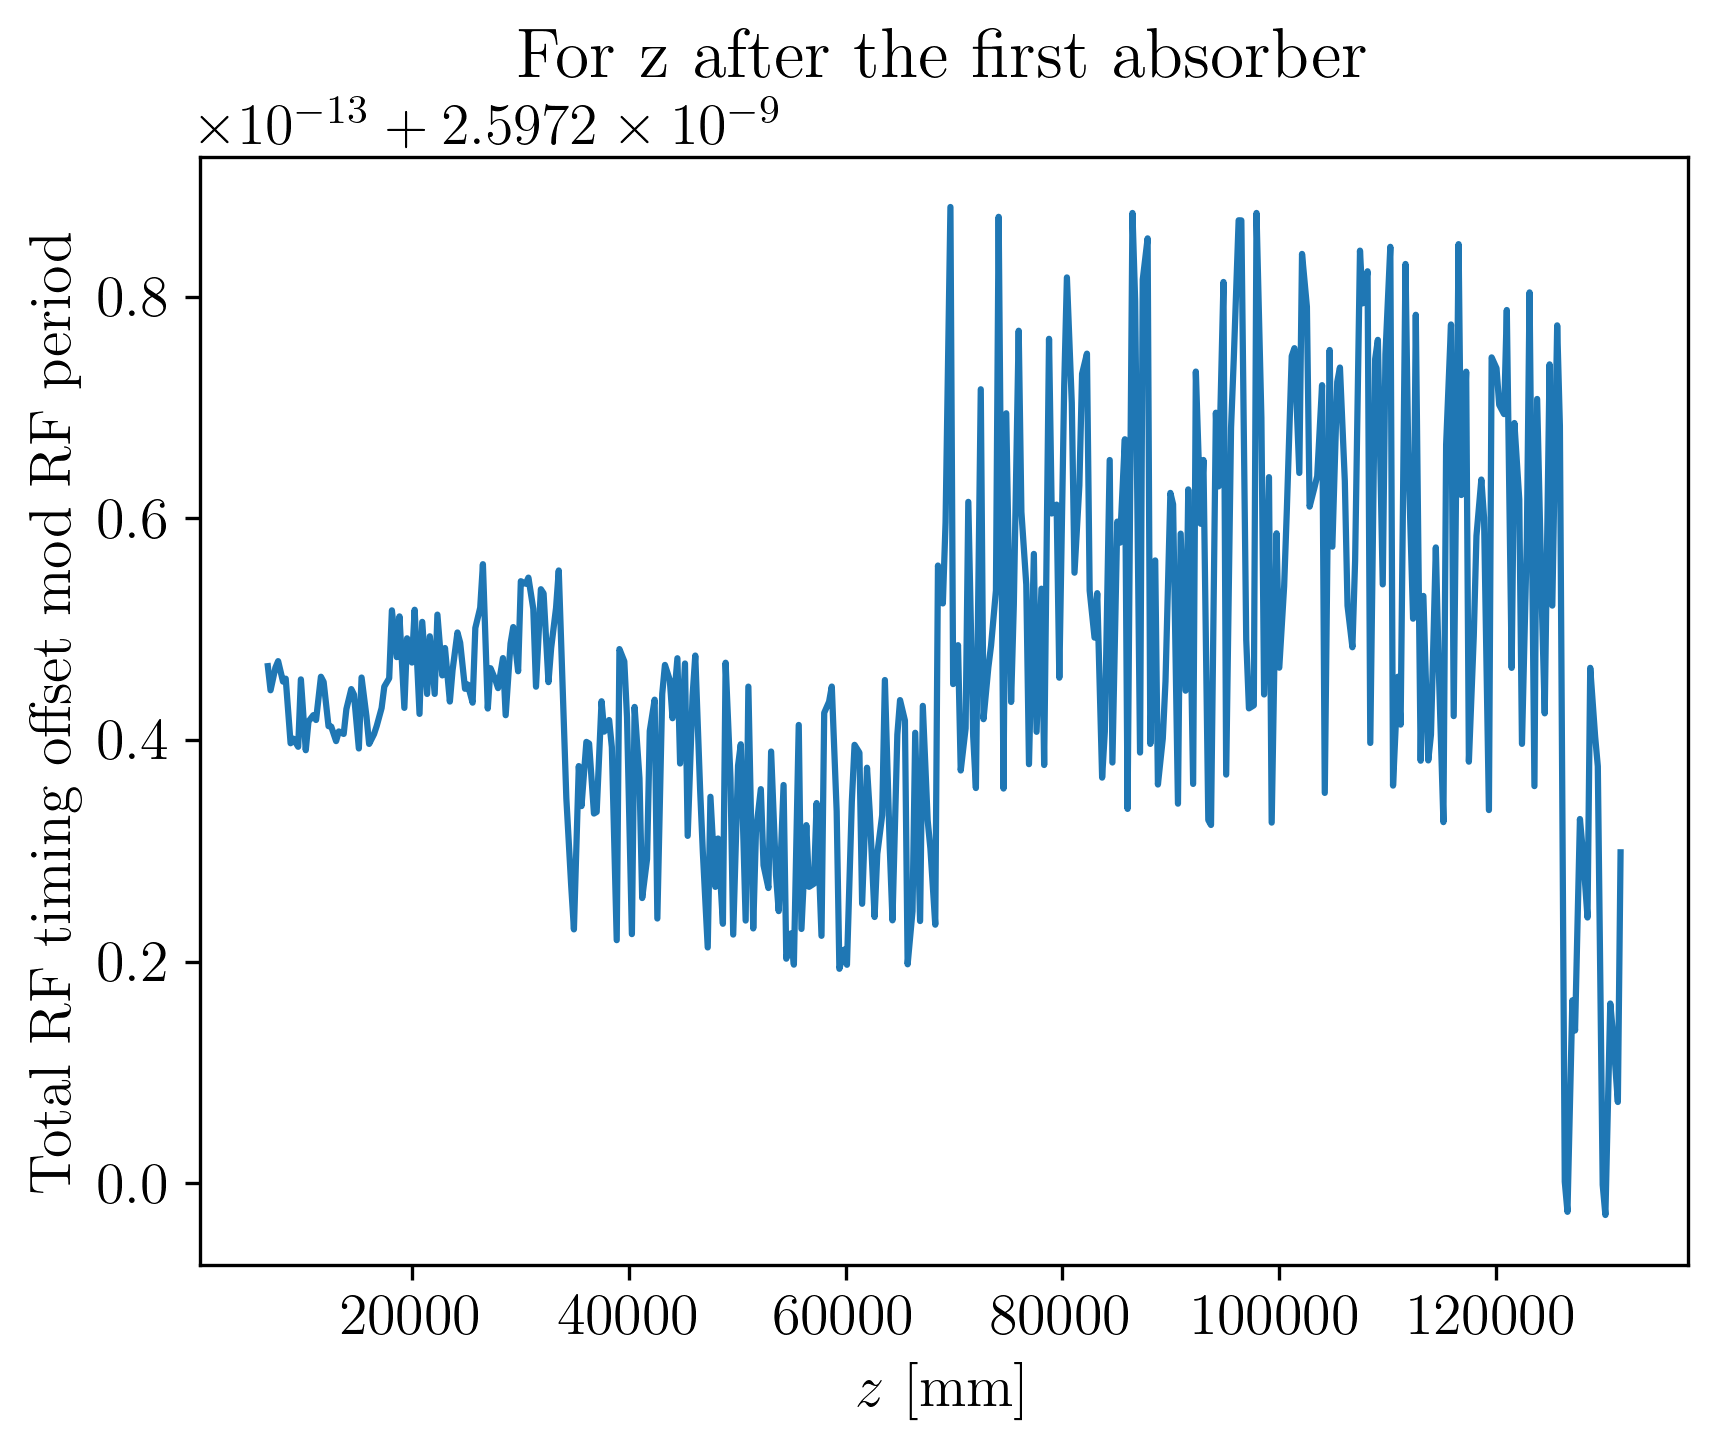

In [16]:
vals = ttotal['z'].values
modvals2 = np.array(modvals)[vals>zabsi]
# plt.scatter(ttotal['z'][ttotal['z']>zabsi], modvals2, s=2, color='black')
plt.plot(ttotal['z'][ttotal['z']>zabsi], modvals2)
plt.xlabel('$z$ [mm]')
plt.ylabel('Total RF timing offset mod RF period')
plt.title('For z after the first absorber');

In [30]:
tdiffs = []
for i in range(len(ttotal)-1):
    tdiffs.append(ttotal['t'][i+1]-ttotal['t'][i])

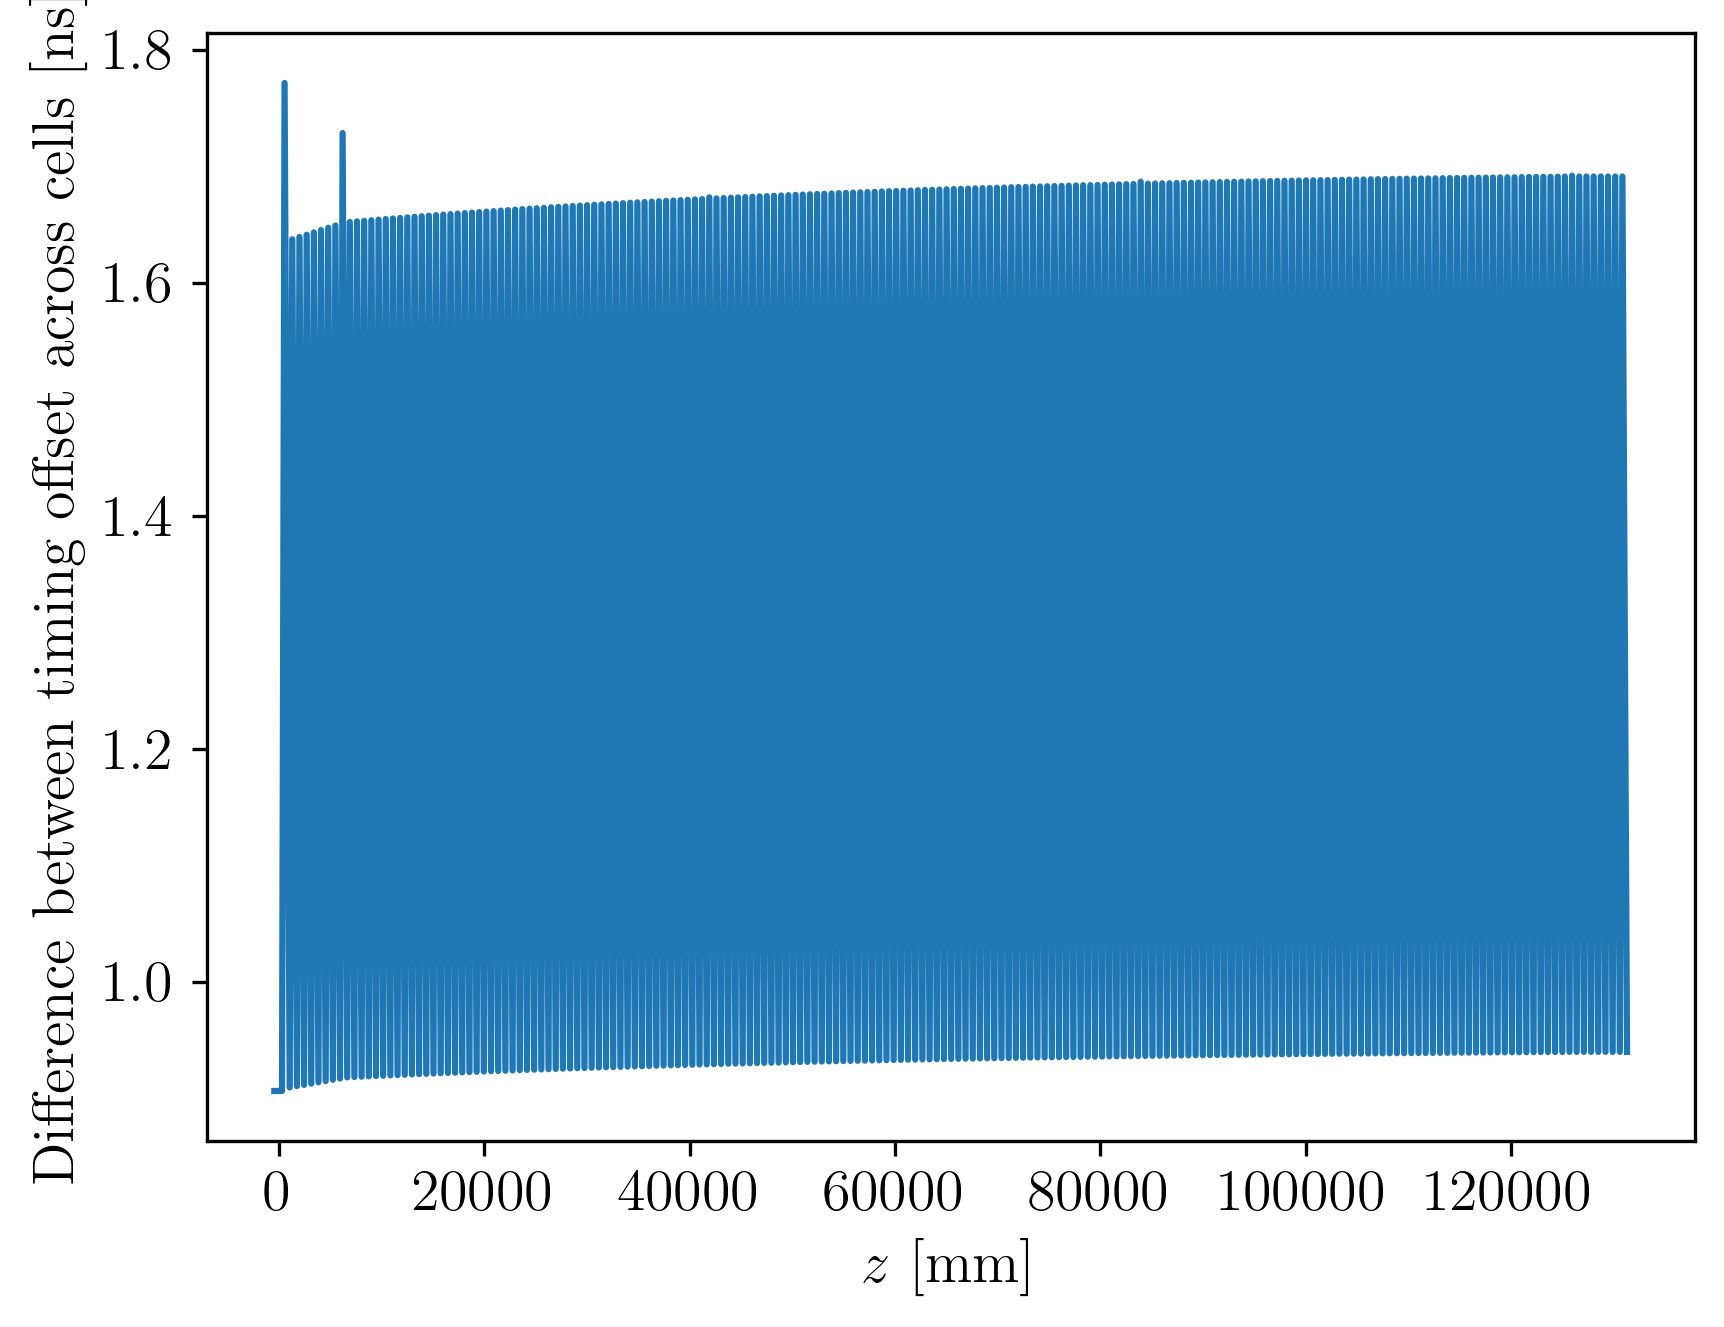

In [38]:
plt.plot(ttotal['z'][:-1],tdiffs)
plt.xlabel('$z$ [mm]')
plt.ylabel('Difference between timing offset across cells [ns]');

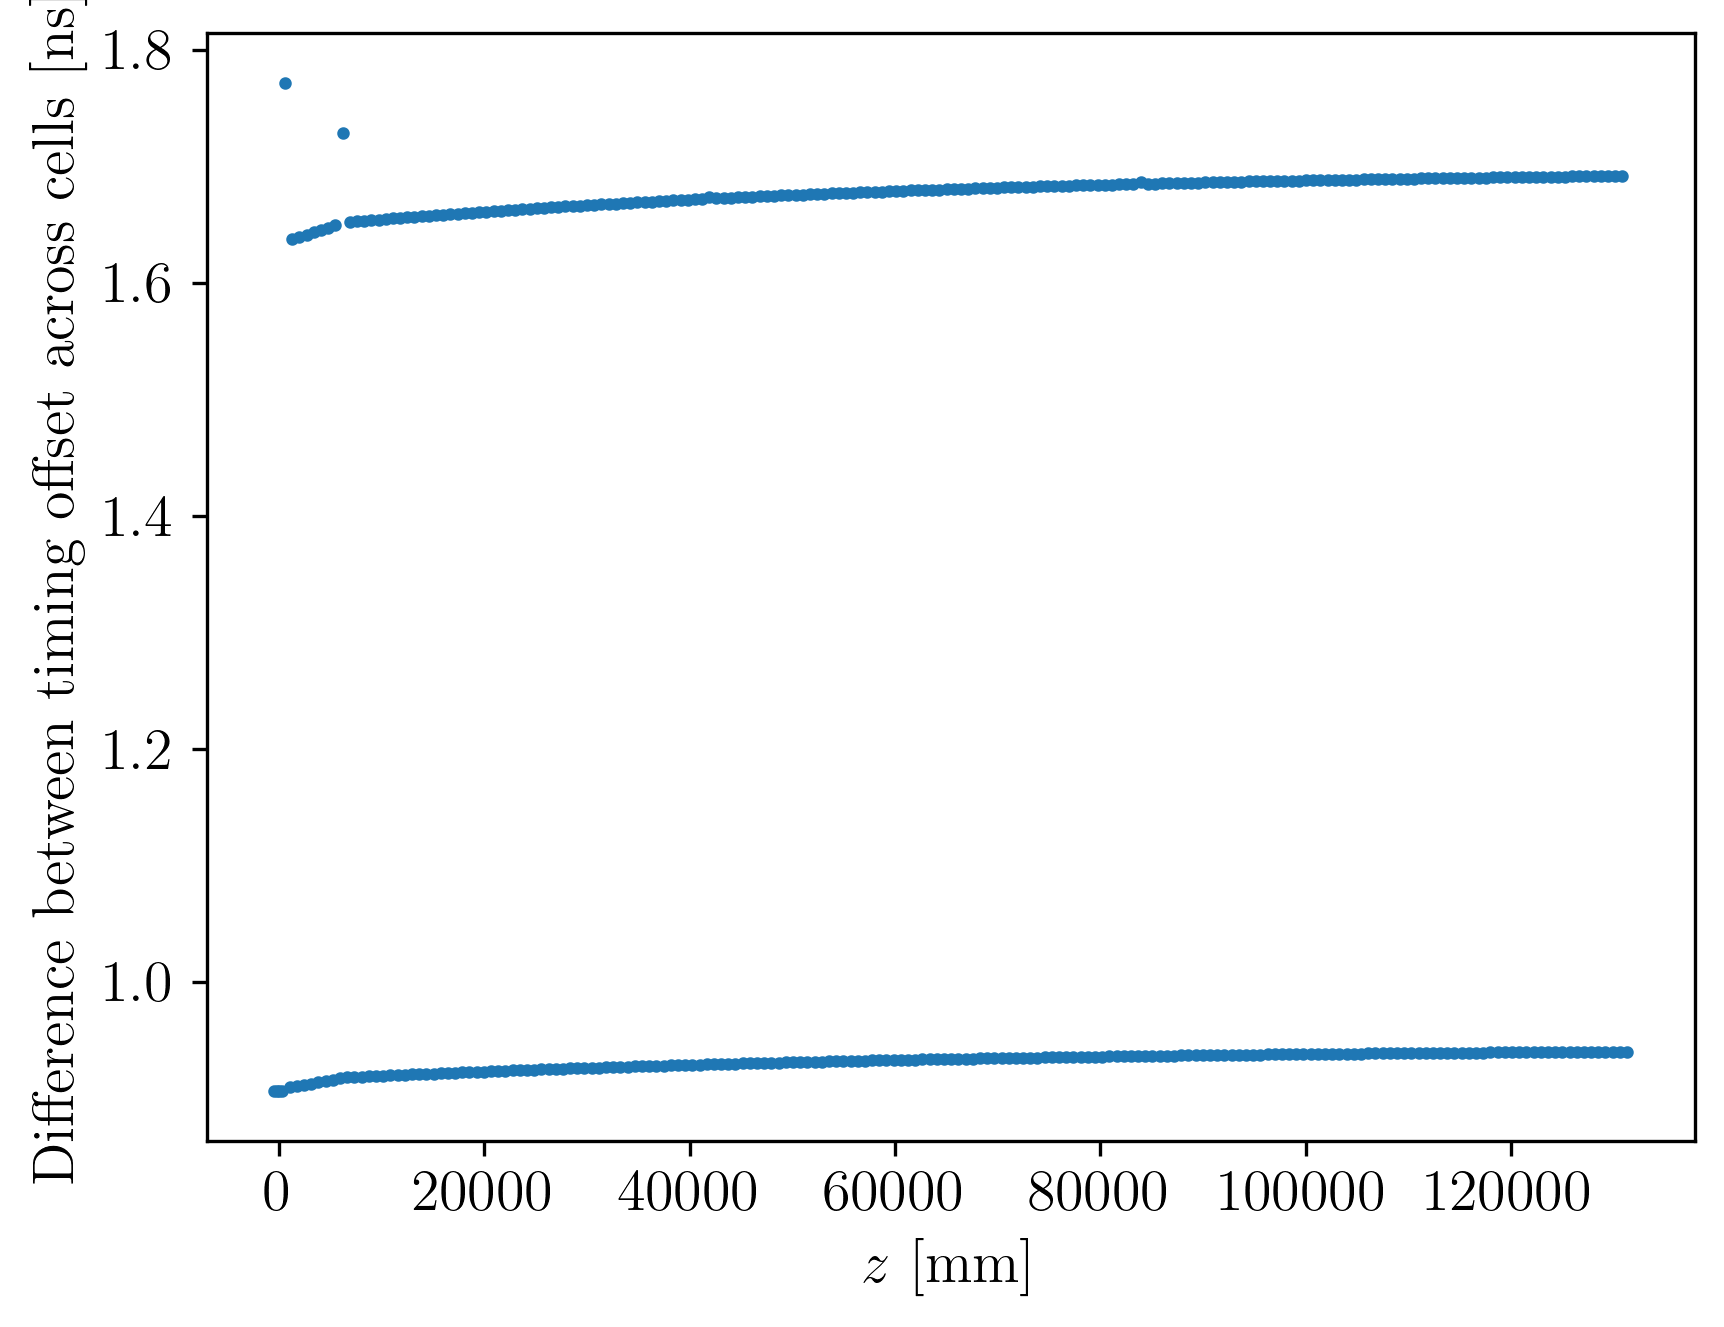

In [42]:
plt.scatter(ttotal['z'][:-1],tdiffs,s=4)
plt.xlabel('$z$ [mm]')
plt.ylabel('Difference between timing offset across cells [ns]');